In [ ]:
import tifffile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os
import pathlib
from scipy.ndimage import distance_transform_edt

import skimage
from skimage.feature import peak_local_max
from skimage import util,  restoration
from skimage.filters import threshold_otsu, threshold_isodata, threshold_li, threshold_minimum, threshold_mean, threshold_yen, threshold_multiotsu, threshold_triangle
from skimage.segmentation import clear_border, expand_labels, watershed
from skimage.measure import label, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, closing,  disk, dilation
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi
from skimage.filters import try_all_threshold
from skimage.filters import gaussian, median as median_filter, threshold_li, threshold_mean, threshold_triangle, threshold_yen
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import closing, disk, square, erosion, remove_small_holes
from skimage.segmentation import watershed, expand_labels
from skimage.feature import peak_local_max
import warnings
warnings.filterwarnings("ignore")
import pathlib
from skimage.morphology import closing,  disk, dilation, erosion, ball
from skimage.measure import regionprops
from skimage.exposure import rescale_intensity
import contextlib
import joblib
from tqdm import tqdm
from joblib import Parallel, delayed

In [3]:
test_image = tifffile.imread(r"Z:\Dorota_Avalon\cytokine array\cytokine array devices\c1\IM000252.Tif")

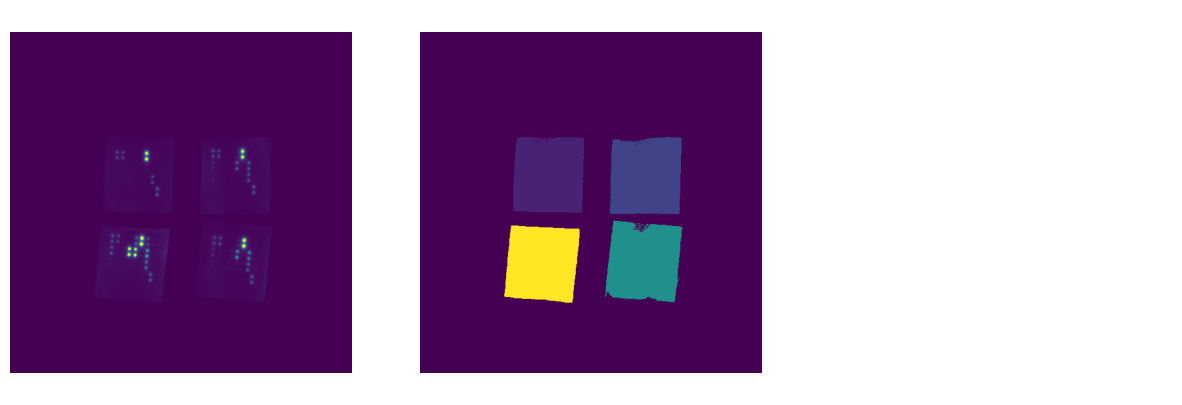

In [4]:
fig, ax = plt.subplots(ncols = 3, figsize = (15, 5))

ax[0].imshow(test_image)
labelled_devices = label(test_image > threshold_li(test_image))
ax[1].imshow(labelled_devices)

for a in ax:
    a.axis("off")

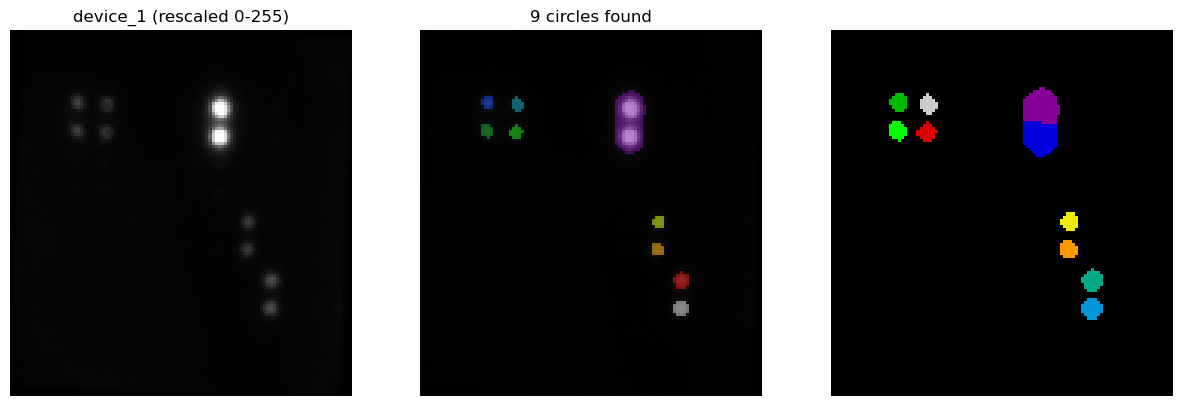

In [58]:


# Crop to the bounding box of the device_1 label
device_mask = labelled_devices == 1
minr, minc, maxr, maxc = regionprops(device_mask.astype(int))[0].bbox

# Rescale intensities to 0-255 within the device region
device_1_rescaled = rescale_intensity(test_image[minr:maxr, minc:maxc].astype(float), out_range=(0, 255))

circles = device_1_rescaled > threshold_li(device_1_rescaled) #threshold_li best so far
labelled_circles = label(circles)

coordinates = peak_local_max(device_1_rescaled, min_distance = int(7)) 
marker_locations = coordinates.data
markers = np.zeros(device_1_rescaled.shape, dtype=np.uint32)
marker_indices = tuple(np.round(marker_locations).astype(int).T)
markers[marker_indices] = np.arange(len(marker_locations)) + 1
segmented = expand_labels(watershed(-device_1_rescaled, markers, mask=labelled_circles>0), distance = 1)


fig, ax = plt.subplots(ncols=3, figsize=(15, 5))
ax[0].imshow(device_1_rescaled, cmap="gray")
ax[0].set_title("device_1 (rescaled 0-255)")
ax[1].imshow(device_1_rescaled, cmap="gray")
ax[1].imshow(labelled_circles, cmap="nipy_spectral", alpha=0.5)
ax[1].set_title(f"{labelled_circles.max()} circles found")
ax[2].imshow(segmented, cmap="nipy_spectral")
for a in ax:
    a.axis("off")
